# CNN con tasa de aprendizaje reducida

En esta practica vamos a aplicar una CNN 1D a los datos de Compostec.

El dataset no tiene imagenes. Tiene variables numericas relacionadas con el proceso de compostaje, por lo que la CNN 1D trabajara con esas variables.

El objetivo es predecir el Score del compost.

In [4]:
%pip install tensorflow pandas numpy matplotlib scikit-learn

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

keras.utils.set_random_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 1. Cargar la data

Se carga el archivo Compost Data.csv y se revisan sus primeras filas.

In [6]:
df = pd.read_csv("/content/Compost Data.csv")

df.head()

,Day,Temperature,MC(%),pH,C/N Ratio,Ammonia(mg/kg),Nitrate(mg/kg),TN(%),TOC(%),EC(ms/cm),OM(%),T Value,GI(%),Score
0,0,35.463,60.0000,5.7345,26.7755,2515.0,325.49,1.80632,48.365121,1.7846,83.381469,1.000000,32.8821,28.042095
1,3,41.866,56.8814,7.1327,23.0494,3449.1,302.42,1.92498,44.369634,2.4366,76.493249,0.860839,39.4615,36.185328
2,6,59.134,53.0847,7.9646,20.4697,5197.6,243.40,1.83675,37.597721,3.0118,64.818472,0.764494,30.5469,37.074037
3,9,53.119,49.4237,8.1770,18.7500,1940.1,203.99,1.78550,33.478125,3.1566,57.716287,0.700267,63.1219,51.246933
4,12,38.955,45.2203,8.0177,17.0303,814.4,200.52,1.91893,32.679954,3.5596,56.340240,0.636040,79.4691,59.698282


## 2. Seleccionar variables

Para el modelo se usan las variables numericas que describen el proceso de compostaje.

El objetivo sera predecir el Score.

No usamos T Value ni GI(%) en este primer modelo porque estan relacionados con la evaluacion del compost y podrian darle al modelo informacion demasiado cercana al resultado que queremos predecir.

In [7]:
variables = [
    "Day",
    "Temperature",
    "MC(%)",
    "pH",
    "C/N Ratio",
    "Ammonia(mg/kg)",
    "Nitrate(mg/kg)",
    "TN(%)",
    "TOC(%)",
    "EC(ms/cm)",
    "OM(%)"
]

objetivo = "Score"

for columna in variables + [objetivo]:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

df[variables + [objetivo]] = df[variables + [objetivo]].replace(
    [np.inf, -np.inf], np.nan
)

display(df[variables + [objetivo]].isna().sum())

assert df[variables + [objetivo]].notna().all().all(), (
    "Hay datos ausentes o invalidos. Revisalos antes de continuar."
)

df = df.drop_duplicates().reset_index(drop=True)

print("Registros:", len(df))
display(df.head())

,0
Day,0
Temperature,0
MC(%),0
pH,0
C/N Ratio,0
Ammonia(mg/kg),0
Nitrate(mg/kg),0
TN(%),0
TOC(%),0
EC(ms/cm),0


Registros: 452


,Day,Temperature,MC(%),pH,C/N Ratio,Ammonia(mg/kg),Nitrate(mg/kg),TN(%),TOC(%),EC(ms/cm),OM(%),T Value,GI(%),Score
0,0,35.463,60.0000,5.7345,26.7755,2515.0,325.49,1.80632,48.365121,1.7846,83.381469,1.000000,32.8821,28.042095
1,3,41.866,56.8814,7.1327,23.0494,3449.1,302.42,1.92498,44.369634,2.4366,76.493249,0.860839,39.4615,36.185328
2,6,59.134,53.0847,7.9646,20.4697,5197.6,243.40,1.83675,37.597721,3.0118,64.818472,0.764494,30.5469,37.074037
3,9,53.119,49.4237,8.1770,18.7500,1940.1,203.99,1.78550,33.478125,3.1566,57.716287,0.700267,63.1219,51.246933
4,12,38.955,45.2203,8.0177,17.0303,814.4,200.52,1.91893,32.679954,3.5596,56.340240,0.636040,79.4691,59.698282


## 3. Separar entrenamiento, validacion y prueba

Separamos la informacion en tres grupos:

- 60 % para entrenamiento
- 20 % para validacion
- 20 % para prueba

La division se hace de forma aleatoria y se usa una semilla fija para obtener siempre la misma separacion.

In [8]:
X = df[variables].copy()
y = df[objetivo].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Entrenamiento:", len(X_train))
print("Validacion:", len(X_val))
print("Prueba:", len(X_test))

Entrenamiento: 271
Validacion: 90
Prueba: 91


## 4. Escalar las variables

Las variables tienen escalas diferentes. Por ejemplo, Temperature, pH y Ammonia(mg/kg) no tienen el mismo rango.

Usamos StandardScaler. El escalador se ajusta solamente con los datos de entrenamiento y despues se aplica a validacion y prueba.

In [9]:
escalador = StandardScaler()

X_train = escalador.fit_transform(X_train)
X_val = escalador.transform(X_val)
X_test = escalador.transform(X_test)

X_train = X_train.astype("float32")
X_val = X_val.astype("float32")
X_test = X_test.astype("float32")

y_train = y_train.to_numpy(dtype="float32")
y_val = y_val.to_numpy(dtype="float32")
y_test = y_test.to_numpy(dtype="float32")

## 5. Preparar los datos para la CNN 1D

Como no tenemos imagenes, cada registro se organiza como una secuencia de sus variables numericas.

Cada muestra tiene 11 variables y un canal. De esta forma la CNN 1D puede trabajar sobre el conjunto de variables sin crear ventanas artificiales de varias filas.

In [10]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_val = X_val.reshape(
    X_val.shape[0],
    X_val.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("Forma del entrenamiento:", X_train.shape)
print("Forma de la validacion:", X_val.shape)
print("Forma de la prueba:", X_test.shape)

Forma del entrenamiento: (271, 11, 1)
Forma de la validacion: (90, 11, 1)
Forma de la prueba: (91, 11, 1)


## 6. Crear la CNN 1D

Se usan capas Conv1D porque los datos estan organizados como una secuencia de variables numericas.

La ultima capa tiene una sola salida porque queremos predecir un valor continuo: el Score.

In [11]:
keras.utils.set_random_seed(42)

modelo_cnn = keras.Sequential([
    keras.Input(
        shape=(len(variables), 1)
    ),

    layers.Conv1D(
        filters=32,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),

    layers.Conv1D(
        filters=16,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),

    layers.GlobalAveragePooling1D(),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dropout(0.1),

    layers.Dense(
        1
    )
])

modelo_cnn.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0003
    ),
    loss="mse",
    metrics=["mae"]
)

modelo_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 11, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 11, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257 (8.82 KB)

 Trainable params: 2,257 (8.82 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento

Ahora entrenamos la CNN con los datos preparados.

Usamos EarlyStopping para detener el entrenamiento cuando la validacion deja de mejorar. La tasa de aprendizaje se mantiene en 0.0003 para que los cambios del modelo sean graduales.

In [12]:
parada_temprana = keras.callbacks.EarlyStopping(
    monitor="val_mae",
    mode="min",
    patience=15,
    restore_best_weights=True
)

historial = modelo_cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    shuffle=True,
    callbacks=[parada_temprana],
    verbose=2
)

Epoch 1/150
9/9 - 2s - 167ms/step - loss: 2896.2229 - mae: 50.6628 - val_loss: 2909.6206 - val_mae: 51.6517
Epoch 2/150
9/9 - 0s - 16ms/step - loss: 2892.1165 - mae: 50.6207 - val_loss: 2905.4050 - val_mae: 51.6101
Epoch 3/150
9/9 - 0s - 17ms/step - loss: 2887.9475 - mae: 50.5785 - val_loss: 2900.8459 - val_mae: 51.5648
Epoch 4/150
9/9 - 0s - 34ms/step - loss: 2882.8535 - mae: 50.5270 - val_loss: 2895.5002 - val_mae: 51.5117
Epoch 5/150
9/9 - 0s - 32ms/step - loss: 2877.2471 - mae: 50.4708 - val_loss: 2888.9902 - val_mae: 51.4470
Epoch 6/150
9/9 - 0s - 37ms/step - loss: 2870.2141 - mae: 50.3984 - val_loss: 2881.2969 - val_mae: 51.3706
Epoch 7/150
9/9 - 0s - 37ms/step - loss: 2862.5122 - mae: 50.3197 - val_loss: 2872.2566 - val_mae: 51.2805
Epoch 8/150
9/9 - 0s - 45ms/step - loss: 2853.3306 - mae: 50.2266 - val_loss: 2861.6379 - val_mae: 51.1744
Epoch 9/150
9/9 - 1s - 61ms/step - loss: 2841.1707 - mae: 50.1024 - val_loss: 2849.0356 - val_mae: 51.0480
Epoch 10/150
9/9 - 0s - 23ms/step - 

## 8. Evaluacion

Se calculan MAE, RMSE y R2 para revisar el comportamiento del modelo.

Tambien se compara el MAE de entrenamiento con el de validacion y se revisa el conjunto de prueba, que se mantuvo separado durante el entrenamiento.

In [13]:
pred_train = modelo_cnn.predict(
    X_train,
    verbose=0
).ravel()

pred_val = modelo_cnn.predict(
    X_val,
    verbose=0
).ravel()

pred_test = modelo_cnn.predict(
    X_test,
    verbose=0
).ravel()

mae_train = mean_absolute_error(
    y_train,
    pred_train
)

mae_val = mean_absolute_error(
    y_val,
    pred_val
)

rmse_val = np.sqrt(
    mean_squared_error(
        y_val,
        pred_val
    )
)

r2_val = r2_score(
    y_val,
    pred_val
)

mae_test = mean_absolute_error(
    y_test,
    pred_test
)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test,
        pred_test
    )
)

r2_test = r2_score(
    y_test,
    pred_test
)

mejor_epoca = (
    np.argmin(
        historial.history["val_mae"]
    ) + 1
)

print(f"Mejor epoca: {mejor_epoca}")
print(f"MAE entrenamiento: {mae_train:.4f}")
print(f"MAE validacion:    {mae_val:.4f}")
print(f"RMSE validacion:   {rmse_val:.4f}")
print(f"R2 validacion:     {r2_val:.4f}")

print("\n--- Prueba reservada ---")
print(f"MAE prueba:  {mae_test:.4f}")
print(f"RMSE prueba: {rmse_test:.4f}")
print(f"R2 prueba:   {r2_test:.4f}")

Mejor epoca: 150
MAE entrenamiento: 13.2271
MAE validacion:    11.8320
RMSE validacion:   14.2805
R2 validacion:     0.1549

--- Prueba reservada ---
MAE prueba:  12.9390
RMSE prueba: 15.8037
R2 prueba:   0.1568


## 9. Curva de entrenamiento

Aqui se observa como cambia el MAE durante el entrenamiento y la validacion.

La linea de validacion no tiene que bajar de forma perfecta. Lo importante es observar donde obtiene su menor error y comparar ese comportamiento con el entrenamiento.

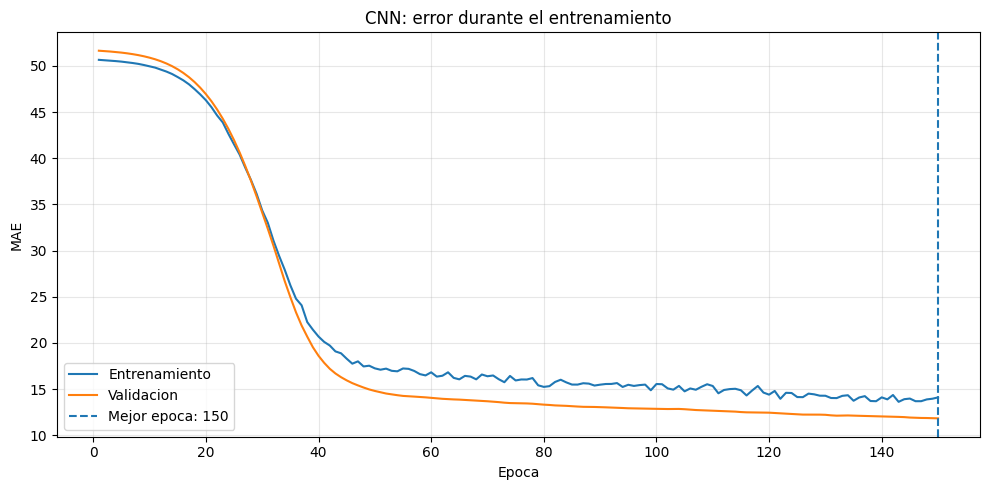

In [14]:
epocas = np.arange(
    1,
    len(historial.history["mae"]) + 1
)

plt.figure(figsize=(10, 5))

plt.plot(
    epocas,
    historial.history["mae"],
    label="Entrenamiento"
)

plt.plot(
    epocas,
    historial.history["val_mae"],
    label="Validacion"
)

plt.axvline(
    mejor_epoca,
    linestyle="--",
    label=f"Mejor epoca: {mejor_epoca}"
)

plt.xlabel("Epoca")
plt.ylabel("MAE")
plt.title("CNN: error durante el entrenamiento")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Comparacion entre valores reales y predichos

Se comparan algunos valores reales con las predicciones realizadas por la CNN sobre el conjunto de validacion.

,Score_real,Score_predicho,Error_absoluto
0,68.233002,49.664001,18.569000
1,54.056999,44.499001,9.559000
2,39.182999,41.028000,1.845000
3,32.890999,44.487999,11.597000
4,49.717999,57.058998,7.341000
5,23.867001,44.743000,20.875999
6,57.978001,46.430000,11.548000
7,64.747002,60.922001,3.825000
8,40.262001,41.090000,0.828000
9,53.403000,36.573002,16.830000


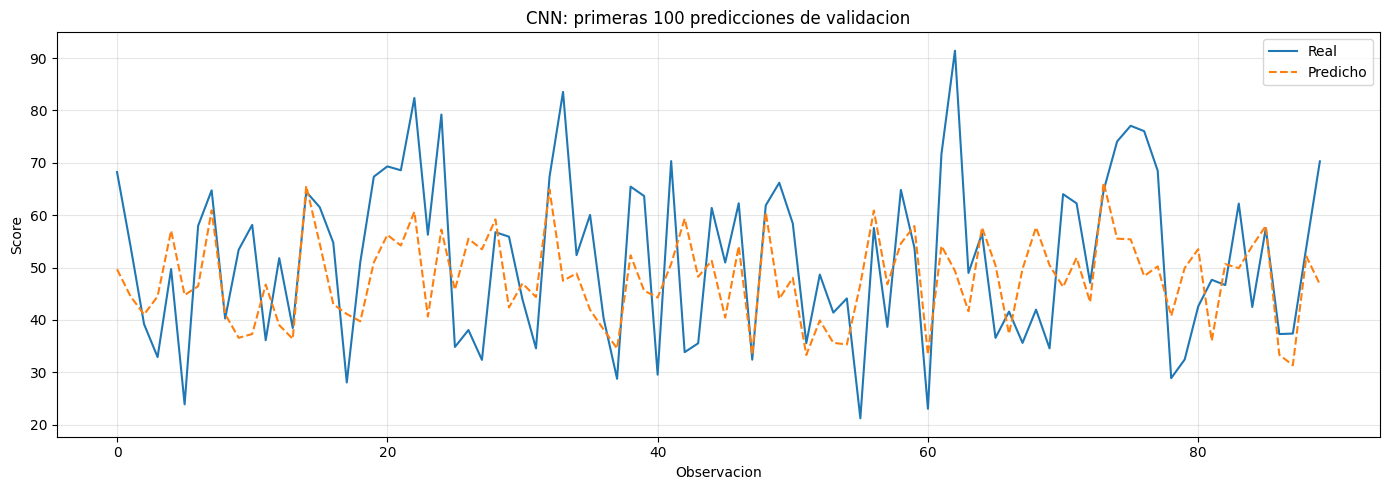

In [15]:
comparacion_cnn = pd.DataFrame({
    "Score_real": y_val,
    "Score_predicho": pred_val
})

comparacion_cnn["Error_absoluto"] = abs(
    comparacion_cnn["Score_real"]
    - comparacion_cnn["Score_predicho"]
)

display(
    comparacion_cnn
    .head(20)
    .round(3)
)

muestra = comparacion_cnn.head(100)

plt.figure(figsize=(14, 5))

plt.plot(
    muestra["Score_real"],
    label="Real"
)

plt.plot(
    muestra["Score_predicho"],
    "--",
    label="Predicho"
)

plt.xlabel("Observacion")
plt.ylabel("Score")
plt.title("CNN: primeras 100 predicciones de validacion")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Resultado

El modelo CNN 1D permite trabajar con el dataset de compostaje sin utilizar imagenes.

En este caso, la entrada esta formada por variables numericas del proceso y la salida corresponde al Score.

Este resultado sirve como una primera prueba de Deep Learning para Compostec. Despues se puede comparar con modelos de Machine Learning como Random Forest o Gradient Boosting.